# Make plots for Griffith & McDermott ARO 2023 poster: Human-like Attentional Selection Emerges as a Solution to the Cocktail Party Problem

### Plots to include:
* [Demo waves and cochlaegrams](#cochleagrams)
* [Attentive listening task:](#Attentive_listening_task)
    * Model & human word correct with 1-talker 4-talker & stationary noise distractors 
    * Model & human confusions with 1-talker distractor
* [Target-distractor sex similarity:](#sex_similarity)
    * Model & human word correct with same/different flags (rows for model & human)
    * add confusions as separate panel, same legend & arrangement 
* [Harmonic vs inharmonic speech from model](#harmonicity)
* [Attenntional gais](#gains)
* [Stream correlations for several architectures on same plot](#corrs)

In [212]:
%matplotlib inline
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['font.family'] = 'Arial'


import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FormatStrFormatter
import numpy as np
from matplotlib import cm

from pathlib import Path

In [155]:
plot_out_dir = Path('/om2/user/imgriff/projects/Auditory-Attention/ARO_2023_figs/')

<a id='cochleagrams'></a>

## Demo cochleagrams & waves

In [233]:
import sys 
sys.path.append('../')
from corpus.jsinV3_attn_multi_talker_w_audioset import jsinV3_attn_multi_talker_w_audioset
import matplotlib
import src.audio_transforms as at
import yaml 

path = Path('../config/attentional_cue/attn_cue_match_target_speech_and_noise.yaml')
config = yaml.load(open(path, 'r'), Loader=yaml.FullLoader)

model_name = path.stem
model_name


'attn_cue_match_target_speech_and_noise'

In [244]:
import src.audio_transforms as at
audio_config = config['data']['audio']

audio_transforms = at.AudioCompose([
    at.AudioToTensor(),
    at.RMSNormalizeForegroundAndBackground(rms_level=0.1), # normalize so all signals at same level pre-mix
    at.CombineWithRandomDBSNR(low_snr=config['noise_kwargs']['low_snr'],
                               high_snr=config['noise_kwargs']['high_snr']),
    at.RMSNormalizeForegroundAndBackground(rms_level=0.1), # set cue to same level as target 
    at.UnsqueezeAudio(dim=0),
#     aat.AudioToAudioRepresentation(**audio_config)
])
# these transforms take foreground, background as input 
bg_combine_transforms = at.AudioCompose([
                at.AudioToTensor(),
                at.CombineWithRandomDBSNR(low_snr=config['noise_kwargs']['low_snr'],
                                          high_snr=config['noise_kwargs']['high_snr']),
                at.RMSNormalizeForegroundAndBackground(rms_level=0.1)
            ])

coch_transform = at.AudioToAudioRepresentation(**audio_config)


In [264]:
# del config['data']['corpus']['n_talkers']
# del config['data']['corpus']['with_audioset']


In [265]:
dataset = jsinV3_attn_multi_talker_w_audioset(**config['data']['corpus'],
#                                           train=False,
                                          mode='val',
                                          n_talkers=1,
                                          with_audioset=False,
                                          transform=[audio_transforms, bg_combine_transforms],
                                          demo=True)


In [266]:
foreground, background, signal, fg_cue, fg_target = dataset[0]

In [280]:
mixture_coch, _ = coch_transform(mixture, None)
cue_coch, _ = coch_transform(cue, None)

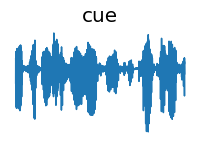

In [326]:
fontsize = 20

plt.figure(figsize=(3.33, 2))
# plt.subplot(2,2,1)
plt.plot(cue.squeeze())
plt.title('cue', fontsize=fontsize)
plt.axis('off');


# out_name = plot_out_dir / 'cue_wavs.svg'
# plt.savefig(out_name, bbox_inches='tight')

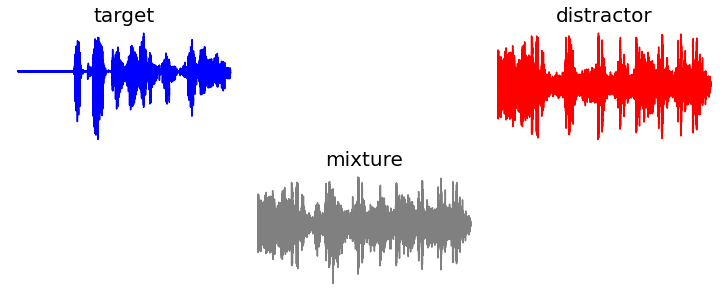

In [324]:
fontsize=20

mosaic = """a.b
            .c."""
fig, axd = plt.subplot_mosaic(mosaic,
                              figsize=(10, 4), layout="constrained",
                             )


axd['a'].plot(foreground.squeeze(), 'b')
axd['a'].set_title('target', fontsize=fontsize)
axd['a'].axis('off');

axd['b'].plot(background.squeeze(), 'r')
axd['b'].set_title('distractor', fontsize=fontsize)
axd['b'].axis('off');

axd['c'].plot(signal.squeeze(), 'grey')
axd['c'].set_title('mixture', fontsize=fontsize)
axd['c'].axis('off');

# out_name = plot_out_dir / 'mix_wavs.svg'
# plt.savefig(out_name, bbox_inches='tight')

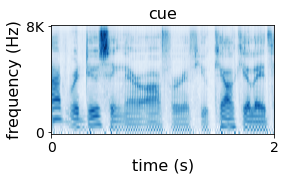

In [312]:
plt.figure(figsize=(4,2))
fontsize=16
plt.imshow(cue_coch.squeeze(), aspect='auto', vmin=cue_coch.min(), vmax=cue_coch.max() * 0.5, cmap=cm.Blues)
# plt.axis('off')
plt.yticks([0,39], ['8K', '0'], fontsize=fontsize-2)
plt.ylabel('frequency (Hz)', fontsize=fontsize)
plt.xticks([0,16000],[0, 2], fontsize=fontsize-2)
plt.xlabel('time (s)', fontsize=fontsize)
plt.title('cue', fontsize=fontsize)
# plt.axis('off')

# out_name = plot_out_dir / 'cue_cochleagram.svg'
# plt.savefig(out_name, bbox_inches='tight')

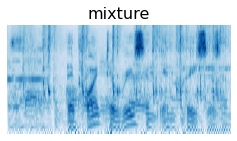

In [313]:
plt.figure(figsize=(4,2))
fontsize=16
plt.imshow(mixture_coch.squeeze(), aspect='auto', 
           vmin=mixture_coch.min(),vmax=mixture_coch.max()*.5,
           cmap=cm.Blues)
# plt.axis('off')
# plt.yticks([0,39], ['10K', '0'], fontsize=fontsize-2)
# plt.ylabel('frequency (Hz)', fontsize=fontsize)
# plt.xticks([0,16000],[0, 2], fontsize=fontsize-2)
# plt.xlabel('time (s)', fontsize=fontsize)
plt.title('mixture', fontsize=fontsize)

plt.axis('off')

# out_name = plot_out_dir / 'mixture_cochleagram.svg'
# plt.savefig(out_name, bbox_inches='tight')

## Make EG sigmiod function 


<function matplotlib.pyplot.tight_layout(*, pad=1.08, h_pad=None, w_pad=None, rect=None)>

findfont: Font family ['Arial'] not found. Falling back to DejaVu Sans.


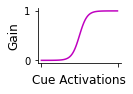

In [217]:

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

n_layers = 5
# c_palette = sns.color_palette("magma", , as_cmap=False)


fig, axs = plt.subplots(1, figsize=(1.5,1))
x = np.linspace(-10,10,100)



sns.despine()
axs.plot(sigmoid(x), 'm')
axs.set_xticklabels('');
plt.xlabel('Cue Activations', fontsize=12)
plt.ylabel('Gain', fontsize=12);
plt.tight_layout

# plt.savefig(plot_out_dir / 'sigmoid.svg',  format="svg", bbox_inches='tight')

In [ ]:
## Process for confusions and sex comparisons

## map male/female to same/different 


def remap_sex_strs(target_sex, distractors):
    if isinstance(distractors,float):
        return distractors
    if distractors == 'noise':
        return distractors 
    same_diff = ''.join(['s' if char == target_sex else 'd' for char in distractors])
    return same_diff

all_results['distractor_type'] = all_results[['target_sex',
                                              'distractor_sex']].apply(lambda x: remap_sex_strs(x.target_sex, x.distractor_sex),
                                                    axis=1)


## Make distractor hue colors 

# distractor_hue_order = [cond for cond in results.distractor_sex.unique().astype('str')
#                         if 'm' in cond or 'f' in cond]

# distractor_hue_order = sorted(distractor_hue_order, key=lambda x: len(x))

from itertools import groupby


distractor_hue_order = ['s', 'd', 'ss', 'sd', 'dd', 'ssss', 'sssd', 'ssdd', 'sddd', 'dddd']

grouped_distractors = [list(set(items)) for length, items in groupby(distractor_hue_order, key=len)]
grouped_distractors = [sorted(elems) for elems in grouped_distractors]

distractor_palette = {}
print(grouped_distractors)

color_palettes = [sns.diverging_palette(220, 20, center="dark", n=2, as_cmap=False),
                sns.diverging_palette(145, 300, center="dark", s=60, n=3, as_cmap=False),
                sns.color_palette("coolwarm", n_colors=5, as_cmap=False)]


for g_ix, group in enumerate(grouped_distractors):
    n_in_group = len(group)
    for d_ix, dist in enumerate(group):
        distractor_palette[dist] = color_palettes[g_ix][d_ix]


distractor_palette['ssdd'] = distractor_palette['sd']

# skip 2 distractor condition
sex_distractor_palette = {k:v for k,v in distractor_palette.items() if len(k) !=2}
sex_distractor_hue_order = ['s', 'd', 'ssss', 'sssd', 'ssdd', 'sddd', 'dddd']


## Get stats for sex similarity plots:

turk_results = all_results[all_results['subject'] == 'human']

turk_by_sex_accuracy_df = (turk_results.groupby(["snr", 'participant',
                                         "distractor_condition", "distractor_type"])
                     .accuracy
                     .agg(["mean"])
                     .reset_index())

turk_by_sex_accuracy_df.rename(columns={'mean':'accuracy'}, inplace=True)
turk_by_sex_confusion_df = (turk_results.groupby(["snr", 'participant',
                                         "distractor_condition", "distractor_type"])
                     .confusions
                     .agg(["mean"])
                     .reset_index())
turk_by_sex_confusion_df.rename(columns={'mean':'confusions'}, inplace=True)




# turk_summary_df = (turk_results.groupby(["snr", 'participant',
#                                          "distractor_condition", "distractor_sex", 'target_sex'])
#                      .accuracy
#                      .agg(["mean"])
#                      .reset_index())

turk_by_sex_accuracy_df.head()

sex_acc = pd.merge(turk_by_sex_accuracy_df, all_results[all_results.subject=='model'], 
        on=['snr', 'participant', 'distractor_condition', 'distractor_type',
       'accuracy'],

        how='outer')
sex_acc['subject'][~sex_acc.participant.isna()] = 'human'

sex_name_update = {'s': "Same", 'd':'Different'}
sex_acc['distractor_type'] = sex_acc['distractor_type'].replace(sex_name_update)
turk_by_sex_confusion_df['distractor_type'] = turk_by_sex_confusion_df['distractor_type'].replace(sex_name_update)
sex_distractor_palette = {(sex_name_update[k] if k in sex_name_update.keys() else k):v 
                          for k,v in sex_distractor_palette.items()}

dist_name_update = {'1': "1 talker", '4':'4 talker', 'noise':'noise'}
turk_summary_df['distractor_condition'] = turk_summary_df['distractor_condition'].replace(dist_name_update)
all_results['distractor_condition'] = all_results['distractor_condition'].replace(dist_name_update)

turk_summary_df.head()

<a id='gains'></a>

## Plost histograms of Attn Gain activations

load data and plot

In [4]:
import pickle
out_file = '../attentional_gain_activations/attn_cue_match_target_speech_and_noise.pkl'

with open(out_file, 'rb') as f:
    acts = pickle.load(f)

In [10]:
import pandas as pd
model_dfs = []
for layer in acts['cue_acts'].keys():
    layer_dict = {'cue_acts': acts['cue_acts'][layer],
                'gain_acts': acts['gain_acts'][layer],
                'layer':[f"{layer}"] * len(acts['cue_acts'][layer])}
#                 'model':[f"{model}"] * len(acts['cue_acts'][layer])}
    layer_df = pd.DataFrame.from_dict(layer_dict)
    model_dfs.append(layer_df)
model_df = pd.concat(model_dfs)


In [13]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def attn_gain(x, bias, slope, threshold):
    return bias + (1-bias) * sigmoid((x - threshold) * slope)
    

In [77]:
def get_sigmoid(acts, layer, n_bins, x=None):
    gain_fn_params = acts['gain_params'][layer]
    cue_acts = acts['cue_acts'][layer]
    
    x_for_fn = x if x is not None else np.linspace(np.abs(cue_acts).min(), np.abs(cue_acts).max(), n_bins)
    bias = gain_fn_params['bias']
    slope = gain_fn_params['slope']
    threshold = gain_fn_params['threshold']
    
    return attn_gain(x_for_fn, bias, slope, threshold).T, x_for_fn
    

    
        

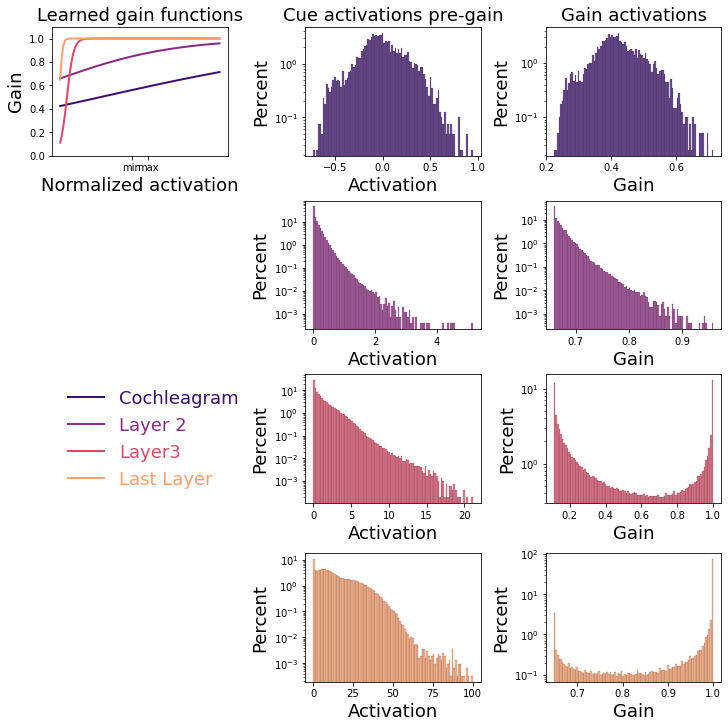

In [330]:
gs_kw = dict(width_ratios=[1, 1, 1], height_ratios=[1, 1, 1, 1])

mosaic = """A12
            .34
            L56
            .78"""
fig, axd = plt.subplot_mosaic(mosaic,
                              figsize=(10, 10), layout="constrained",
                              gridspec_kw=gs_kw)

c_palette = sns.color_palette("magma", 4, as_cmap=False)


n_hist_bins = 100
pad = 8
layer_names = model_df.layer.unique()



gain_demo_layers = [name for name in layer_names if any(key in name for key in ['in', '2','3','6'])]

layer_row_dict = {layer : (str(i), str(i+1)) for layer, i in zip(gain_demo_layers , range(1,9, 2))}

x_min = -1
x_max = 1
# x = np.linspace(x_min,x_max,100)

init_bias = 0
init_slope = 1
init_threshod = 0


layer_names = ['Cochleagram', "Layer 2", "Layer3", "Last Layer"]

layer_name_dict = {df_name:h_name for df_name, h_name in zip(gain_demo_layers, layer_names)}

init_filter = attn_gain(x, init_bias, init_slope, init_threshod)


# axd["A"].plot(x, init_filter, linewidth=2, c='k', ls='--', label='Initialization') # linewidth=4,

fontsize=18

for ix, layer in enumerate(gain_demo_layers):
    gain_filter, input_act_vals = get_sigmoid(acts, layer, n_hist_bins)    
        
    axd["A"].plot(x, gain_filter, linewidth=2, c=c_palette[ix], label=layer_name_dict[layer]) # linewidth=4,
    
    # plot hist of cue activations    
    sns.histplot(data=model_df[model_df.layer == layer], x='cue_acts',
             stat='percent',  log_scale=(False, True), edgecolor='0.1',
#              hue='model', hue_order=hue_order, palette=model_palette,
             color=c_palette[ix], bins=n_hist_bins, ax=axd[layer_row_dict[layer][0]])

    # plot hist of gains
    sns.histplot(data=model_df[model_df.layer == layer], x='gain_acts',
                 stat='percent',  log_scale=(False, True), edgecolor='0.1',
#                  hue='model', hue_order=hue_order, palette=model_palette,
                 color=c_palette[ix], bins=n_hist_bins, ax=axd[layer_row_dict[layer][1]])
    
    axd[layer_row_dict[layer][0]].set_xlabel("Activation", fontsize=fontsize)
    axd[layer_row_dict[layer][0]].set_ylabel("Percent", fontsize=fontsize)

    axd[layer_row_dict[layer][1]].set_xlabel("Gain", fontsize=fontsize)
    axd[layer_row_dict[layer][1]].set_ylabel("Percent", fontsize=fontsize)
    
#     axd[layer_row_dict[layer][0]].set_ylim((10**-3,10**2))
#     axd[layer_row_dict[layer][1]].set_ylim((10**-3,10**2))



axd['1'].set_title("Cue activations pre-gain", fontsize=fontsize)
axd['2'].set_title("Gain activations", fontsize=fontsize)

axd["A"].set_title("Learned gain functions", fontsize=fontsize)
axd["A"].set_ylabel("Gain", fontsize=fontsize)
axd["A"].set_xlabel("Normalized activation", fontsize=fontsize)
axd["A"].set_xticks([x_min, x_max])

axd["A"].set_xticklabels(["min", "max"])
axd["A"].set_ylim(0,1.1)

handles, labels = axd["A"].get_legend_handles_labels()
leg = axd["L"].legend(handles, labels,
                      fontsize=fontsize,
                      frameon=False,
                      loc='center left',
#                       handlelength=0,
#                       markerscale=0,
#                       handletextpad=-1.0,
                      labelcolor= c_palette)
                      #bbox_to_anchor=[-0.05, 0, 1, 1])
leg.get_frame().set_facecolor('none')
leg.get_frame().set_edgecolor('none')
# leg.get_frame().set_linewidth(.3)
axd['L'].axis('off')

# plt.subplots_adjust(hspace=1)


# plt.subplots_adjust(wspace=0.8)
plt.savefig("../ARO_2023_figs/attn_gains_v2.pdf")